In [1]:
import sys
import torch

print("Python executable:", sys.executable)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Python executable: c:\Users\harsh\DL_CW_2\.venv_gpu311\Scripts\python.exe
PyTorch version: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU
Using device: cuda


## Imports and Runtime Setup

The libraries required for transfer learning, optimisation, evaluation, and visualisation were imported for the EfficientNet experiment. The computation device was also verified so that GPU acceleration could be used during model training when available.

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Subset

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# A fixed seed is used so that the experimental setup remains reproducible.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# CUDA-based randomness is also controlled when GPU execution is available.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# The active computation device is selected for model training.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Dataset and Transform Setup

The retinal OCT dataset was prepared using the original training directory and the official test directory. A controlled 80/20 split was created from the training set to obtain a sufficiently large validation subset, while the test set remained untouched for final evaluation.

The preprocessing pipeline preserves retinal OCT structure while applying conservative augmentation to the training subset.

In [3]:
# The dataset root is defined using the confirmed local project path.
dataset_root = Path(r"C:\Users\harsh\DL_CW_2\data\raw\OCT2017\OCT2017")

train_root = dataset_root / "train"
test_root = dataset_root / "test"

# A standard input size is used for all retinal OCT images.
IMAGE_SIZE = 224
BATCH_SIZE = 32

# The training transform applies conservative augmentation while preserving anatomical consistency.
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        fill=0
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# The evaluation transform standardises images without stochastic augmentation.
eval_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# The original training directory is first loaded without transforms so that a reproducible split can be created.
full_train_dataset = datasets.ImageFolder(train_root)

# The class labels are recovered from the original training dataset.
class_names = full_train_dataset.classes
num_classes = len(class_names)

# A controlled 80/20 train-validation split is created from the original training data.
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_subset_raw, val_subset_raw = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# The training directory is loaded twice so that different transforms can be assigned to train and validation subsets.
train_dataset_full = datasets.ImageFolder(train_root, transform=train_transforms)
val_dataset_full = datasets.ImageFolder(train_root, transform=eval_transforms)

# The split indices are reused so that the transformed datasets follow the same partitioning.
train_subset = Subset(train_dataset_full, train_subset_raw.indices)
val_subset = Subset(val_dataset_full, val_subset_raw.indices)

# The official test set is kept untouched for final evaluation.
test_dataset = datasets.ImageFolder(test_root, transform=eval_transforms)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Train samples:", len(train_subset))
print("Validation samples:", len(val_subset))
print("Test samples:", len(test_dataset))

Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Number of classes: 4
Train samples: 66787
Validation samples: 16697
Test samples: 968


## Dataloader Construction

PyTorch dataloaders were prepared to provide efficient mini-batch processing during model training and evaluation. Shuffling was applied only to the training loader, while validation and test loaders remained deterministic.

In [4]:
# The dataloaders are configured for efficient mini-batch processing across all stages of the experiment.
train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train loader batches:", len(train_loader))
print("Validation loader batches:", len(val_loader))
print("Test loader batches:", len(test_loader))

Train loader batches: 2088
Validation loader batches: 522
Test loader batches: 31


## Batch Verification

A sample training batch was retrieved to confirm that the data pipeline produces tensors with the expected dimensions and datatype required by the EfficientNet architecture.

In [5]:
# A sample batch is retrieved to verify tensor dimensions and label structure before model training.
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Batch data type:", images.dtype)
print("Sample labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Batch data type: torch.float32
Sample labels: tensor([0, 3, 3, 0, 3, 3, 2, 0, 3, 2])


## EfficientNet Architecture

A pretrained EfficientNet-B0 model was adopted for retinal OCT classification. Transfer learning was used so that the model could benefit from feature representations learned from large-scale image data.

The original classifier was replaced with a new output layer matching the four retinal OCT classes. The deeper feature extraction stages were partially fine-tuned so that the model could adapt to domain-specific retinal patterns.

In [6]:
# A pretrained EfficientNet-B0 model is loaded for transfer learning.
weights = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

# All pretrained parameters are initially frozen.
for param in model.parameters():
    param.requires_grad = False

# The last feature block is unfrozen so that the model can adapt to retinal OCT patterns.
for param in model.features[-1].parameters():
    param.requires_grad = True

# The classifier is replaced to match the number of retinal disease classes.
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, num_classes)
)

# The updated classifier remains trainable.
for param in model.classifier.parameters():
    param.requires_grad = True

# The model is moved to the selected computation device.
model = model.to(device)

print("EfficientNet-B0 ready")
print("Model is on device:", device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\harsh/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 45.6MB/s]


EfficientNet-B0 ready
Model is on device: cuda


## Training Configuration

The EfficientNet model was trained using cross-entropy loss for multi-class classification. The optimiser was configured to update only the trainable parameters, including the unfrozen final feature block and the new classification head.

A lower learning rate was adopted to support stable fine-tuning of pretrained weights.

In [7]:
# Cross-entropy loss is used for the multi-class retinal OCT classification task.
criterion = nn.CrossEntropyLoss()

# Only trainable parameters are passed to the optimiser so that frozen weights remain unchanged.
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

EPOCHS = 10

print("Loss function configured successfully.")
print("Optimizer configured successfully.")
print("Epochs:", EPOCHS)

Loss function configured successfully.
Optimizer configured successfully.
Epochs: 10


## Model Training

The pretrained EfficientNet-B0 model was trained and evaluated across multiple epochs using the training and validation loaders. Both loss and accuracy were recorded so that convergence behaviour and generalisation performance could be analysed in detail.

In [ ]:
# Lists are prepared to store epoch-wise training and validation metrics.
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(EPOCHS):

    #TRAINING 
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    #VALIDATION
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

Epoch 01/10 | Train Loss: 0.5812 | Train Acc: 0.7949 | Val Loss: 0.4254 | Val Acc: 0.8493
Epoch 02/10 | Train Loss: 0.4305 | Train Acc: 0.8478 | Val Loss: 0.3749 | Val Acc: 0.8655
Epoch 03/10 | Train Loss: 0.3984 | Train Acc: 0.8580 | Val Loss: 0.3882 | Val Acc: 0.8600
Epoch 04/10 | Train Loss: 0.3786 | Train Acc: 0.8650 | Val Loss: 0.3659 | Val Acc: 0.8687
Epoch 05/10 | Train Loss: 0.3634 | Train Acc: 0.8715 | Val Loss: 0.3202 | Val Acc: 0.8890
Epoch 06/10 | Train Loss: 0.3565 | Train Acc: 0.8735 | Val Loss: 0.3171 | Val Acc: 0.8881
Epoch 07/10 | Train Loss: 0.3427 | Train Acc: 0.8789 | Val Loss: 0.3036 | Val Acc: 0.8956
Epoch 08/10 | Train Loss: 0.3379 | Train Acc: 0.8811 | Val Loss: 0.3085 | Val Acc: 0.8932
Epoch 09/10 | Train Loss: 0.3357 | Train Acc: 0.8801 | Val Loss: 0.2958 | Val Acc: 0.8986
Epoch 10/10 | Train Loss: 0.3267 | Train Acc: 0.8846 | Val Loss: 0.2884 | Val Acc: 0.8996


## Training and Validation Loss Curves

The loss curves were plotted to analyse the optimisation behaviour of the EfficientNet-B0 model across epochs. A gradual decrease in both training and validation loss indicates stable learning.

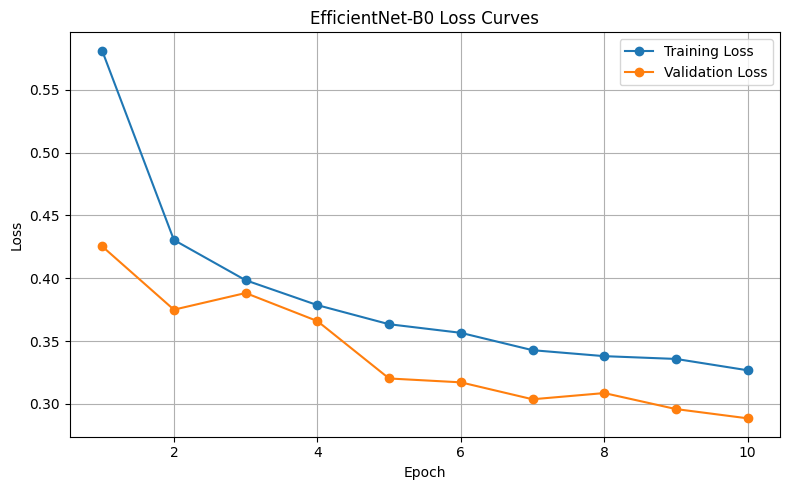

In [9]:
import matplotlib.pyplot as plt

# The loss values recorded across epochs are visualised to examine convergence behaviour.
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', label="Training Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, marker='o', label="Validation Loss")
plt.title("EfficientNet-B0 Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Training and Validation Accuracy Curves

The accuracy curves were plotted to examine how classification performance evolved during training. Comparing training and validation accuracy helps assess generalisation behaviour.

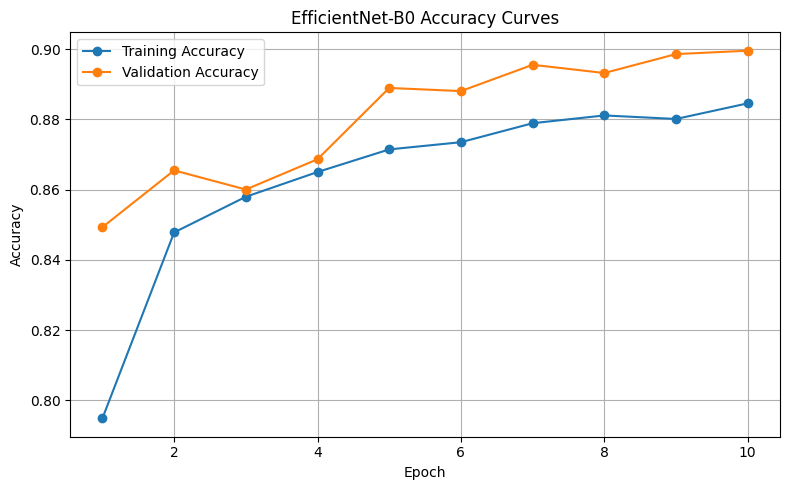

In [10]:
# The accuracy values recorded across epochs are visualised to assess model learning and generalisation.
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_accuracies, marker='o', label="Training Accuracy")
plt.plot(range(1, EPOCHS + 1), val_accuracies, marker='o', label="Validation Accuracy")
plt.title("EfficientNet-B0 Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Model Checkpoint Saving

The trained EfficientNet-B0 model was saved after training so that its learned parameters could be reused for final evaluation and later comparison with other models.

In [11]:
from pathlib import Path
import torch

# The checkpoint directory is created if it does not already exist.
checkpoint_dir = Path("outputs/checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

# The trained model parameters are saved for later reuse and comparison.
checkpoint_path = checkpoint_dir / "efficientnet_b0.pth"
torch.save(model.state_dict(), checkpoint_path)

print("EfficientNet-B0 model saved to:", checkpoint_path)

EfficientNet-B0 model saved to: outputs\checkpoints\efficientnet_b0.pth


## Test Set Evaluation

The EfficientNet-B0 model was evaluated on the held-out test set to obtain an unbiased estimate of its performance on unseen retinal OCT images.

In [12]:
from sklearn.metrics import accuracy_score

# Containers are prepared to collect ground-truth labels and predictions across the full test set.
all_labels = []
all_predictions = []

# The model is evaluated on the unseen test set without gradient computation.
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(preds.cpu().numpy())

# The overall test accuracy is computed as a summary measure of model performance.
test_accuracy = accuracy_score(all_labels, all_predictions)
print("EfficientNet-B0 Test Accuracy:", round(test_accuracy, 4))

EfficientNet-B0 Test Accuracy: 0.9225


## Classification Report

A class-wise classification report was generated to summarise precision, recall, and F1-score for each retinal condition. These metrics provide a more detailed view of performance than overall accuracy alone.

In [13]:
from sklearn.metrics import classification_report
import pandas as pd

# A detailed class-wise performance summary is generated from the test predictions.
report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
CNV,0.816949,0.995868,0.897579,242.000000
DME,0.991071,0.917355,0.952790,242.000000
DRUSEN,0.989529,0.780992,0.872979,242.000000
NORMAL,0.934109,0.995868,0.964000,242.000000
accuracy,0.922521,0.922521,0.922521,0.922521
macro avg,0.932914,0.922521,0.921837,968.000000
weighted avg,0.932914,0.922521,0.921837,968.000000


## Confusion Matrix

A confusion matrix was computed to show how EfficientNet-B0 distributed its predictions across the retinal disease classes. This helps identify the categories that remain challenging for the model.

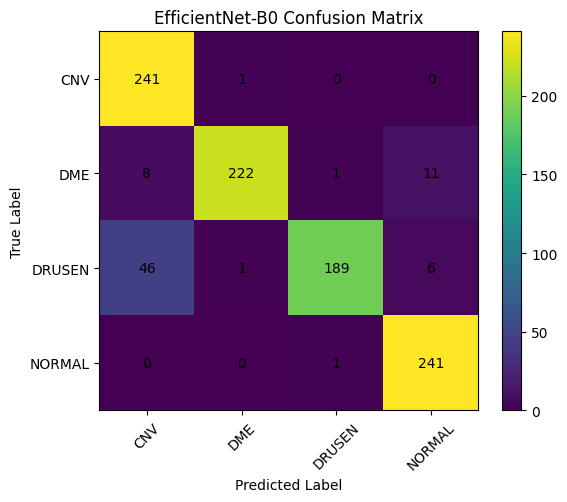

Confusion Matrix:
 [[241   1   0   0]
 [  8 222   1  11]
 [ 46   1 189   6]
 [  0   0   1 241]]


In [14]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# The confusion matrix is computed to analyse the distribution of correct and incorrect predictions.
cm = confusion_matrix(all_labels, all_predictions)

# The matrix is visualised as a heatmap-style figure for easier interpretation.
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("EfficientNet-B0 Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# The values are displayed inside each cell to preserve exact count interpretation.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("Confusion Matrix:\n", cm)

## EfficientNet-B0 Results Summary

A summary table was created to record the key performance indicators of EfficientNet-B0 and support direct comparison with the baseline custom CNN and fine-tuned ResNet50.

In [15]:
# The key EfficientNet-B0 results are organised into a compact summary table for later comparison.
summary_df_efficientnet = pd.DataFrame({
    "Model": ["EfficientNet-B0"],
    "Best Validation Accuracy": [max(val_accuracies)],
    "Final Train Accuracy": [train_accuracies[-1]],
    "Final Validation Accuracy": [val_accuracies[-1]],
    "Final Train Loss": [train_losses[-1]],
    "Final Validation Loss": [val_losses[-1]],
    "Test Accuracy": [test_accuracy]
})

summary_df_efficientnet

,Model,Best Validation Accuracy,Final Train Accuracy,Final Validation Accuracy,Final Train Loss,Final Validation Loss,Test Accuracy
0,EfficientNet-B0,0.899563,0.884573,0.899563,0.326671,0.288411,0.922521


In [16]:
from pathlib import Path

# The metrics directory is created so that tables can be preserved systematically.
metrics_dir = Path("outputs/metrics")
metrics_dir.mkdir(parents=True, exist_ok=True)

# The summary table and classification report are saved for later reuse during report writing.
summary_df_efficientnet.to_csv(metrics_dir / "efficientnet_b0_summary.csv", index=False)
report_df.to_csv(metrics_dir / "efficientnet_b0_classification_report.csv")

print("EfficientNet-B0 metrics saved successfully.")

EfficientNet-B0 metrics saved successfully.


## EfficientNet-B0 Observations

The EfficientNet-B0 model demonstrated stable and consistent learning behaviour throughout training, with both training and validation loss decreasing gradually across epochs. The accuracy curves show smooth convergence, indicating that the model was able to learn meaningful feature representations from retinal OCT images.

The final validation accuracy approached 90%, while the test accuracy reached approximately 92.25%, confirming reasonable generalisation performance. Unlike the custom CNN, EfficientNet exhibited more stable learning without sudden fluctuations, although its overall performance remained lower than that of the fine-tuned ResNet50 model.

The confusion matrix reveals that EfficientNet struggled particularly with the DRUSEN class, where a significant number of samples were misclassified as CNV. This indicates that the model had difficulty distinguishing between visually similar retinal conditions. Additionally, some misclassification was observed in the DME class, suggesting limitations in capturing subtle disease-specific patterns.

Overall, while EfficientNet-B0 provided a stable and efficient architecture, it did not achieve the same level of performance as ResNet50, highlighting that deeper residual feature adaptation was more effective for this medical imaging task.

### EfficientNet-B0 Report Note

EfficientNet-B0 was evaluated as an additional pretrained architecture to extend the model comparison beyond the custom CNN baseline and the fine-tuned ResNet50 model. The model achieved a test accuracy of approximately 92.25%, demonstrating stable convergence and reasonable generalisation.

However, its performance remained lower than both the custom CNN and ResNet50 models, particularly due to reduced recall in the DRUSEN class. This suggests that, despite its parameter-efficient design, EfficientNet-B0 was less effective at capturing fine-grained retinal features required for accurate classification.

These results emphasise that model performance in specialised medical imaging tasks depends not only on architectural efficiency but also on the ability to adapt deep feature representations to domain-specific patterns.

## Model Comparison

A comparative analysis was conducted across three models: a custom CNN baseline, EfficientNet-B0, and a fine-tuned ResNet50 model. Each model was evaluated using consistent preprocessing, a controlled 80/20 train–validation split, and an untouched test set to ensure fair comparison.

### Quantitative Comparison

| Model | Test Accuracy | Validation Accuracy | Key Characteristics |
|------|-------------|-------------------|-------------------|
| Custom CNN | 93.70% | ~94% | Strong baseline, simpler architecture |
| EfficientNet-B0 | 92.25% | ~90% | Stable learning, parameter-efficient |
| ResNet50 (Fine-tuned) | **98.86%** | ~96% | Best performance, deep feature adaptation |

### Performance Analysis

The custom CNN model established a strong baseline, achieving competitive performance despite its relatively simple architecture. It demonstrated good generalisation but showed limitations in distinguishing between visually similar retinal conditions, particularly DRUSEN and CNV.

EfficientNet-B0 exhibited stable and consistent learning behaviour, with smooth convergence across training epochs. However, its overall performance was slightly lower than the custom CNN. The confusion matrix indicated that EfficientNet struggled with DRUSEN classification, often misclassifying it as CNV. This suggests that its parameter-efficient design may not have been sufficient to capture fine-grained retinal features required for this task.

The fine-tuned ResNet50 model significantly outperformed both alternatives, achieving the highest test accuracy. Its residual architecture and deeper feature representation enabled more effective learning of complex retinal structures. Fine-tuning further improved domain adaptation, leading to better class separation and reduced misclassification across all categories.

### Key Insights

- Transfer learning significantly improves performance in medical imaging tasks.
- Fine-tuning pretrained models is essential for adapting to domain-specific patterns.
- Model architecture plays a critical role in capturing subtle visual differences.
- Efficient models do not always outperform deeper architectures in specialised tasks.
- DRUSEN classification remains the most challenging category across models.

### Summary

Overall, ResNet50 emerged as the most effective model for retinal OCT classification, providing superior accuracy and generalisation. While the custom CNN and EfficientNet-B0 offered valuable baseline and comparative insights, the results demonstrate that deeper residual architectures are better suited for complex medical image analysis.